In [1]:
# Import modules
import numpy as np
import time

from gem.fragment import Fragment
from gem.lattice import Lattice
from gem.solvers.simple_ed import SimpleED


/Users/sgiuli/TRIQS-GHOSTGA/new_venv/lib/python3.12/site-packages/gem/utility/utilities.py:52: SyntaxWarning: invalid escape sequence '\L'
  """ Compute Lambda matrix from R, D, Lambda_c and Delta. It comes from the same equation as for Lambda_c. Lambda is expressed as


In [45]:
# Setup physical parameters
nimp = 2 # number of impurity levels (including spin), 1 orbital is 2 levels (spin up and down)
B = 3 # number of bath replicas (B=1 corresponds to standard GA)
nbath = nimp*B # total number of bath levels
ntot = nimp + nbath # total number of levels in the fragment

T = 0.0 # temperature
mu = 0.0 # chemical potential

U_list=np.linspace(0.5,4.0,8) # list of interaction values to scan

# construct ek with semicircular DOS
# of half-bandwidth D=1, and corresponding weights wk
e_list = np.linspace(-1, 1, 10001)
wks = np.sqrt(1 - e_list**2)
wks /= np.sum(wks)
eks = []
for e in e_list:
    tmp = np.array([[1.0*e]],dtype=np.complex128)
    tmp = np.kron(tmp,np.eye(2))
    eks.append(tmp)
eks = np.array(eks)

In [46]:
# parameters for the loop
itmax = 100 # maximum number of iterations
tol = 1e-4 # convergence tolerance
mix = 0.5 # mixing parameter for the self-consistency loop
spin_pen = 0.0 # spin penalty term to enforce spin-singlet ground state in the impurity solver

In [50]:
# starting matrices None means the fragment will initialize them with some standard values
Lambda0=None
R0=None

#Build the lattice objects for the calculation
lattice = Lattice(eks, wk_list=wks)

w_list = np.linspace(-3., 3., 501)
Z_list = [] # list to store the quasiparticle weights for each U
Gloc_list = [] # list to store the local Green's function for each U

for iU, U in enumerate(U_list):
    
    # Construct local Hamiltonian for the fragment
    eloc = np.zeros((nimp, nimp))
    eloc[0,0] = -U/2.
    eloc[1,1] = -U/2.
    # Construct the interaction tensor for the fragment
    Utensor = np.zeros((nimp, nimp, nimp, nimp))
    Utensor[0,0,1,1] = U
    Utensor[1,1,0,0] = U

    # Construct the fragment object
    edsolver = SimpleED(ntot, use_Ntot=True, use_Sz=True,
                        N_sector=ntot//2, Sz_sector=0,
                        dtype=np.complex128)
    fragment = Fragment(nimp, nbath, eloc, Utensor, edsolver, Lambda=Lambda0, R=R0, verbose=2)

    for it in range(itmax):

        # Step 1: solve the lattice problem to get the new update matrices for the hybridization
        lattice.solve_qp([fragment], T=T)

        # Step 2: update the hybridization parameters of the fragment
        fragment.update_hybridization(T=T)

        # Step 3: solve the impurity problem to get the new update matrices for the self-energy
        fragment.solve_impurity(mu, T=T, num_eig=1, spin_pen=spin_pen)

        Lambda_old = fragment.Lambda.copy()
        R_old = fragment.R.copy()

        # Step 4: update the self-energy parameters of the fragment
        fragment.update_self_energy(T=T)


        # Step 5: check for convergence and linear mixing
        Lambda_new = fragment.Lambda
        R_new = fragment.R

        L_eval_new, UL_new = np.linalg.eigh(Lambda_new[::2,::2])
        L_eval_old, UL_old = np.linalg.eigh(Lambda_old[::2,::2])

        diff_R = np.abs(np.abs(UL_old @ R_old[::2,::2]) - np.abs(UL_new @ R_new[::2,::2])).max()
        diff_Lambda = np.abs(L_eval_new - L_eval_old).max()
        diff = max(diff_R, diff_Lambda)

        fragment.Lambda = (1 - mix) * Lambda_new + mix * Lambda_old
        fragment.R = (1 - mix) * R_new + mix * R_old

        # Step 5.1: Impose symmetries on the self-energy and hybridization parameters to improve convergence and ensure physical consistency
        fragment.impose_spin_SU2_symmetry()

        print(f"iteration: {it}  diff={diff}")

        if (diff < tol and it > 2):
            print(f"----- ghost-RISB converged with diff={diff} -----")
            break
        elif( it == itmax - 1):
            print(f"----- ghost-RISB did not converge after {itmax} iterations, final diff={diff} -----")
            break
    Z = fragment.compute_Z()
    print(f'Done with U={U} returning Z={np.diag(Z.real)}')

    Lambda0 = fragment.Lambda.copy()
    R0 = fragment.R.copy()
    Z_list.append(Z[0,0].real)
    print(f'Computing Gloc for U={U}...')
    Gloc_list.append(lattice.compute_Gloc(w_list, [fragment]))

##### END OF LATTICE INITIALIZATION #####
Sector 0 (N=4, Sz=0): basis size = 36
initial R matrix =
[[0.59476874 0.        ]
 [0.         0.59476874]
 [0.58700591 0.        ]
 [0.         0.58700591]
 [0.00229298 0.        ]
 [0.         0.00229298]]
initial Lambda matrix =
[[-0.76159416 -0.          0.          0.          0.          0.        ]
 [-0.         -0.76159416  0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.76159416  0.        ]
 [ 0.          0.          0.          0.          0.          0.76159416]]
initial D matrix =
[[0.91914296 0.        ]
 [0.         0.91914296]
 [0.48461831 0.        ]
 [0.         0.48461831]
 [0.08779506 0.        ]
 [0.         0.08779506]]
initial Lambda_c matrix =
[[-0.76159416 -0.          0.          0.          0.          0.        ]
 [-0

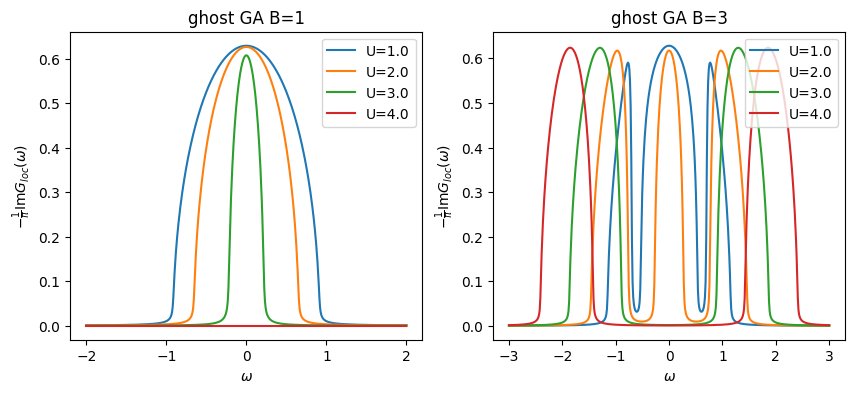

In [61]:
Gloc_list_B3=Gloc_list.copy()
w_list_B3=w_list.copy()
fig, axs = plt.subplots(1, 2, figsize=(10,4))
for iU,U in enumerate(U_list):
    if iU%2==0 : continue
    axs[0].plot(w_list_B1, -(1/np.pi)*Gloc_list_B1[iU][:,0,0].imag, label=f'U={U:.1f}')
    axs[1].plot(w_list, -(1/np.pi)*Gloc_list_B3[iU][:,0,0].imag, label=f'U={U:.1f}')

for i in range(2):
    axs[i].set_xlabel(r'$\omega$')
    axs[i].set_ylabel(r'$-\frac{1}{\pi} \mathrm{Im} G_{loc}(\omega)$')
    axs[i].legend(loc='upper right')
axs[0].set_title('ghost GA B=1')
axs[1].set_title('ghost GA B=3')
plt.savefig('Example_1_fig_2.png', dpi=300)


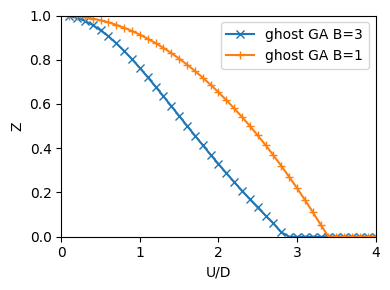

In [35]:

plt.figure(figsize=(4,3))

plt.plot(U_B3, Z_B3, label='ghost GA B=3', marker='x')
plt.plot(U_B1, Z_B1, label='ghost GA B=1', marker='+')

plt.xlabel('U/D')
plt.ylabel('Z')
plt.legend()
plt.ylim(0,1)
plt.xlim(0,4)
plt.tight_layout()
plt.savefig('Example_1_fig_1.png', dpi=300)

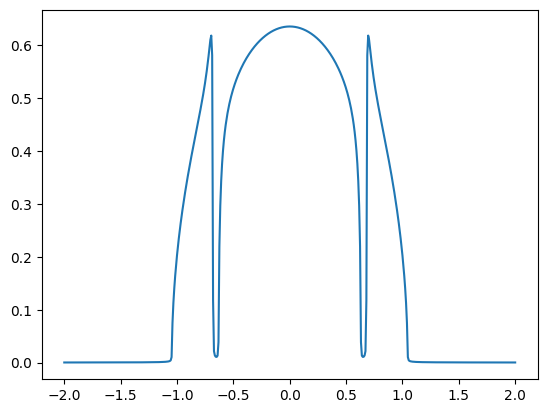

In [30]:
import matplotlib.pyplot as plt
plt.plot(w_list, -(1/np.pi)*Gloc[:,0,0].imag,marker='')


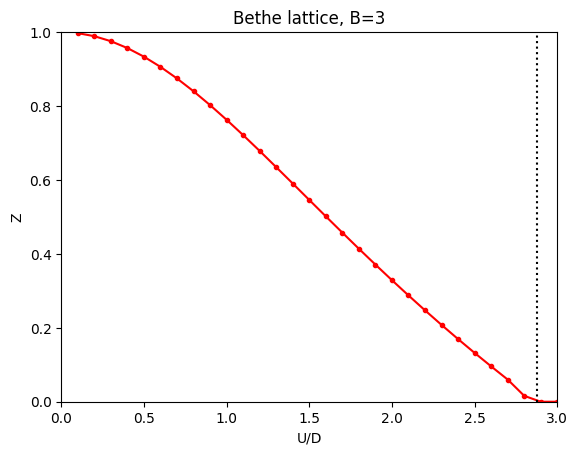

In [20]:
# Plot Z vs U

import matplotlib.pyplot as plt

plt.figure()
plt.plot(U_list, Z_list,marker='.',color='red')
plt.ylabel('Z')
plt.xlabel('U/D')
plt.title(f'Bethe lattice, B={B}')
plt.savefig(f'Z_vs_U_B{B}.png', dpi=100)
plt.axvline(2.88,color='black',linestyle=':')
plt.ylim(0,1)
plt.xlim(0,3)
plt.show()

In [14]:
# Plot Im Gloc vs w for all U
plt.figure()
for iU, U in enumerate(U_list):
    plt.plot(w_list.real, -Gloc_list[iU][:,0,0].imag, label=f'U={U}')
plt.xlabel('Frequency (w)')
plt.ylabel('-Im Gloc')
plt.title('Local Green\'s function Im Gloc vs Frequency for different U')
plt.legend()
#plt.savefig('ImGloc_vs_w_B{B}.png', dpi=100)
plt.show()

IndexError: list index out of range

<Figure size 640x480 with 0 Axes>